# HR Attrition Analysis — End-to-end (EDA + Logistic Regression baseline)

This single notebook contains data loading, EDA, preprocessing, model training (Logistic Regression baseline with class-weighting and simple hyperparameter search), evaluation, and model export.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Path to dataset - update if needed
dataset_path = r"C:\Shinil\IITM Pravartak\Professional Certificate Programme in Generative AI and Machine Learning\Python\Projects\Assignments\WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(dataset_path)
print('Loaded', df.shape, 'rows')
df.head()


Loaded (1470, 35) rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Quick dataset info
print('Attrition counts:')
print(df['Attrition'].value_counts())
print('')
print('Missing values:')
print(df.isnull().sum())
print('')
print('Data types:')
print(df.dtypes)


Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkL

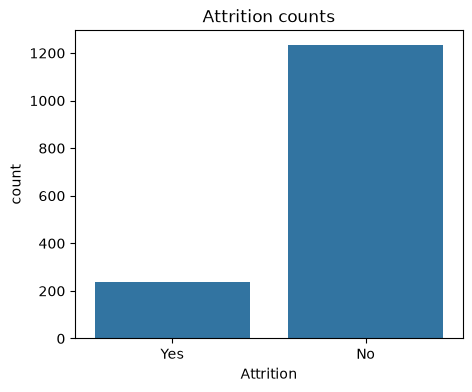

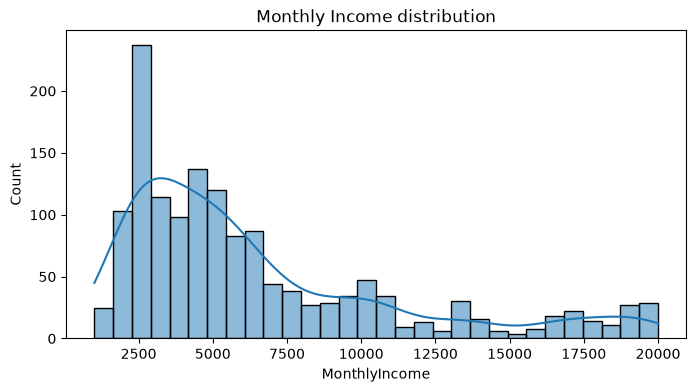

In [3]:
# Simple visualisations
plt.figure(figsize=(5,4))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition counts')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True)
plt.title('Monthly Income distribution')
plt.show()


## Preprocessing & Logistic Regression baseline
The pipeline below: drop identifier-like columns, encode categoricals with OneHotEncoder, scale numeric features, train logistic regression with class_weight='balanced', tune C with GridSearchCV, evaluate on held-out test set, and save model + metrics to outputs/.

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import joblib

# Copy dataset and drop identifier-like columns
df2 = df.copy()
drop_cols = ['EmployeeNumber','EmployeeCount','Over18','StandardHours']
for c in drop_cols:
    if c in df2.columns:
        df2 = df2.drop(columns=c)

X = df2.drop(columns=['Attrition'])
y = df2['Attrition'].map({'Yes':1,'No':0})

numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category','string']).columns.tolist()
print('Numeric cols:', numeric_cols)
print('Some categorical cols:', categorical_cols[:10])

# Preprocessor
numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_cols), ('cat', categorical_transformer, categorical_cols)])

clf = Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
param_grid = {'clf__C':[0.01,0.1,1,10]}
gs = GridSearchCV(clf, param_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
best = gs.best_estimator_
print('Best params:', gs.best_params_)
y_proba = best.predict_proba(X_test)[:,1]
y_pred = best.predict(X_test)
roc = roc_auc_score(y_test, y_proba)
print('Test ROC AUC:', roc)
print('')
print('Classification report:')
print(classification_report(y_test, y_pred, digits=4))
print('')
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

# Save model and metrics
outdir = Path('outputs')
outdir.mkdir(exist_ok=True)
joblib.dump(best, outdir / 'model.pkl')
metrics_text = f"roc_auc: {roc}\nbest_params: {gs.best_params_}\n"
(outdir / 'metrics.txt').write_text(metrics_text)
print('Saved outputs/model.pkl and outputs/metrics.txt')


Numeric cols: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Some categorical cols: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Fitting 5 folds for each of 4 candidates, totalling 20 fits


Best params: {'clf__C': 0.1}
Test ROC AUC: 0.8120423809113619

Classification report:
              precision    recall  f1-score   support

           0     0.9282    0.7854    0.8509       247
           1     0.3765    0.6809    0.4848        47

    accuracy                         0.7687       294
   macro avg     0.6524    0.7331    0.6679       294
weighted avg     0.8400    0.7687    0.7924       294


Confusion matrix:
[[194  53]
 [ 15  32]]
Saved outputs/model.pkl and outputs/metrics.txt


## Next steps and recommendations
- Try SMOTE and compare with class_weight approach
- Train tree-based models (Decision Tree, RandomForest, XGBoost) and compare ROC-AUC and PR-AUC
- Use SHAP or coefficients to explain important features influencing attrition
- Create report.pdf summarizing findings and recommendations
